# Analyse des relation entre les labels , genre musical et les récompences

In [1]:
### Librairies externes à ajouter le cas échéant à l'environnement Python actif

from SPARQLWrapper import SPARQLWrapper, JSON, TURTLE, XML, RDFXML

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import networkx as nx

### Librairies déjà installées avec Python

import pprint
import csv
import sys

from importlib import reload



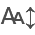

In [2]:
### Module de visualisation de données
#  https://mwouts.github.io/itables/quick_start.html

from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=False)

In [3]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')


import sparql_functions as spqf

## Importer les donnée à analyser

In [36]:
## define SPARQL enpoint
endpoint_url = "https://ag13s8z3wvmae0kr.allegrograph.cloud/repositories/rappers"   # À adapter si nécessaire
graph_uri = "https://github.com/Ziedellouzi/rappers/blob/main/graphs/wikidata-imported-data.md"


In [37]:
# 3. Fonction pour exécuter une requête SPARQL
def run_sparql_query(query):
    """
    Fonction pour exécuter une requête SPARQL sur l'endpoint AllegroGraph et récupérer les résultats.
    """
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    return sparql.query().convert()

# 4. Définition des requêtes SPARQL pour chaque variable (genre musical, label, récompense)
queries = {
    "genre": f"""
        PREFIX wdt: <http://www.wikidata.org/prop/direct/>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT ?genreLabel (COUNT(*) AS ?n)
        WHERE {{
          GRAPH <{graph_uri}> {{
            ?person wdt:P136 ?genre.
            ?genre rdfs:label ?genreLabel.
          }}
        }}
        GROUP BY ?genreLabel
        ORDER BY DESC(?n)
        LIMIT 10000
    """,
    
    "label": f"""
        PREFIX wdt: <http://www.wikidata.org/prop/direct/>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT ?labelName (COUNT(*) AS ?n)
        WHERE {{
          GRAPH <{graph_uri}> {{
            ?person wdt:P264 ?labelEntity.
            ?labelEntity rdfs:label ?labelName.
          }}
        }}
        GROUP BY ?labelName
        ORDER BY DESC(?n)
        LIMIT 10000
    """,
    
    "award": f"""
        PREFIX wdt: <http://www.wikidata.org/prop/direct/>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT ?awardLabel (COUNT(*) AS ?n)
        WHERE {{
          GRAPH <{graph_uri}> {{
            ?person wdt:P166 ?award.
            ?award rdfs:label ?awardLabel.
          }}
        }}
        GROUP BY ?awardLabel
        ORDER BY DESC(?n)
        LIMIT 10000
    """
}

# 5. Récupérer les données avec les requêtes
results = {}
for key, query in queries.items():
    data = run_sparql_query(query)
    
    # On vérifie les noms exacts des clés pour chaque type de donnée
    if key == "genre":
        values = [(r["genreLabel"]["value"], int(r["n"]["value"])) for r in data["results"]["bindings"]]
    elif key == "label":
        values = [(r["labelName"]["value"], int(r["n"]["value"])) for r in data["results"]["bindings"]]
    elif key == "award":
        values = [(r["awardLabel"]["value"], int(r["n"]["value"])) for r in data["results"]["bindings"]]
    
    # Création d'un DataFrame avec les bonnes colonnes
    df = pd.DataFrame(values, columns=[f"{key}_label", "count"])
    results[key] = df

# 6. Afficher les résultats récupérés
# Les données sont stockées dans le dictionnaire `results` avec les clés 'genre', 'label', 'award'
# Examinons les premières lignes des données récupérées pour chaque variable
for key, df in results.items():
    print(f"First few rows for {key} data:\n", df.head(), "\n")


First few rows for genre data:
         genre_label  count
0           hip-hop   3127
1        trap music    520
2           rapping    465
3  contemporary R&B    378
4         pop music    364 

First few rows for label data:
              label_label  count
0       Atlantic Records    135
1     Interscope Records    104
2     Def Jam Recordings    100
3  Universal Music Group     89
4       Columbia Records     88 

First few rows for award data:
                                      award_label  count
0  Grammy Award for Best Melodic Rap Performance     16
1                 star on Hollywood Walk of Fame     14
2                             Silver Play Button     13
3           Victory of the album of urban musics     11
4                                    The Headies     10 



## les distributions

### distributions des genres musicale

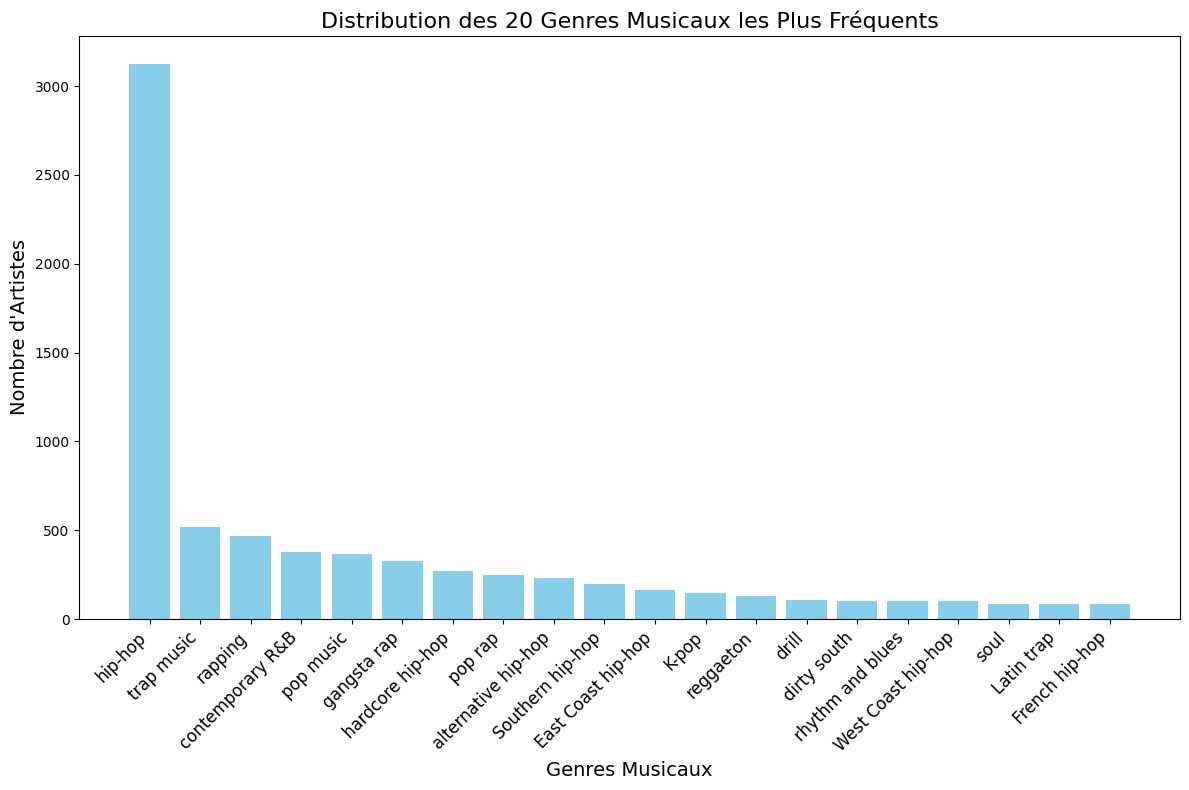

In [12]:
# 1. Création du barplot pour les genres musicaux


# Récupérer les données nettoyées des genres
genre_df = results["genre"]

# 1. Création du barplot pour les genres musicaux avec amélioration de la lisibilité
plt.figure(figsize=(12, 8))  # Augmenter la taille de la figure pour plus de clarté

# Limiter les genres à afficher (par exemple, afficher seulement les 20 premiers genres)
top_genres = genre_df.head(20)

# Création du barplot
plt.bar(top_genres["genre_label"], top_genres["count"], color='skyblue')

# Ajouter le titre et les labels
plt.title("Distribution des 20 Genres Musicaux les Plus Fréquents", fontsize=16)
plt.xlabel("Genres Musicaux", fontsize=14)
plt.ylabel("Nombre d'Artistes", fontsize=14)

# Rotation des étiquettes pour les rendre lisibles
plt.xticks(rotation=45, ha="right", fontsize=12)

# Ajuster la mise en page pour éviter que les labels se chevauchent
plt.tight_layout()

# Afficher le plot
plt.show()


### distribution des labels musicaux 

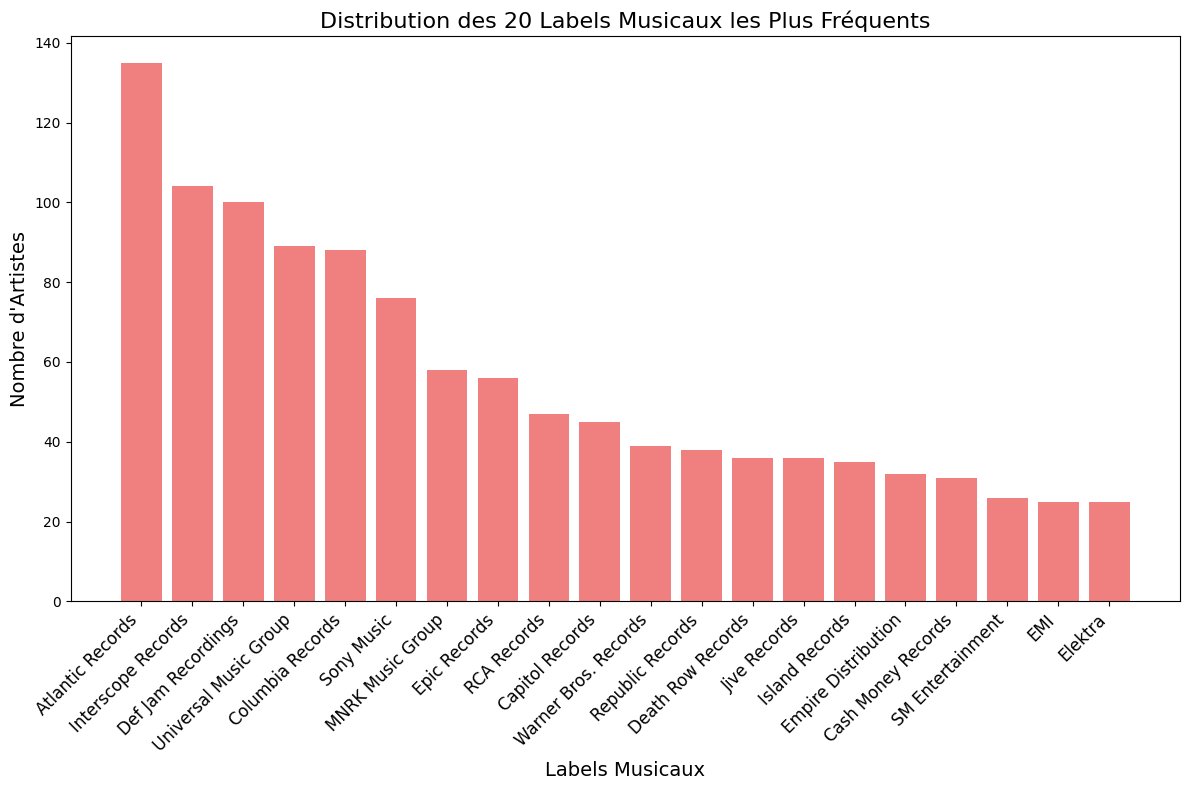

In [14]:
# 1. Création du barplot pour les labels musicaux avec amélioration de la lisibilité
plt.figure(figsize=(12, 8))  # Augmenter la taille de la figure pour plus de clarté

# Limiter les labels à afficher (par exemple, afficher seulement les 20 premiers labels)
top_labels = results["label"].head(20)

# Création du barplot
plt.bar(top_labels["label_label"], top_labels["count"], color='lightcoral')

# Ajouter le titre et les labels
plt.title("Distribution des 20 Labels Musicaux les Plus Fréquents", fontsize=16)
plt.xlabel("Labels Musicaux", fontsize=14)
plt.ylabel("Nombre d'Artistes", fontsize=14)

# Rotation des étiquettes pour les rendre lisibles
plt.xticks(rotation=45, ha="right", fontsize=12)

# Ajuster la mise en page pour éviter que les labels se chevauchent
plt.tight_layout()

# Afficher le plot
plt.show()


### distribution des récompences 

In [48]:
# Fusionner les genres et les récompenses via les artistes (si nous avons des identifiants d'artistes)
# Supposons qu'il y ait un identifiant d'artiste dans les DataFrames de genres et récompenses

# Exemple de fusion avec un identifiant d'artiste (adapte cette partie en fonction de tes données)
artist_genre_award_df = pd.merge(results["genre"], results["award"], how='inner', left_on='artist_id', right_on='artist_id')

# Vérifier si la fusion a fonctionné
print(artist_genre_award_df.head())

# Créer une table croisée pour observer la relation entre genres et récompenses
artist_genre_award_cross_tab = pd.crosstab(artist_genre_award_df["award_label"], artist_genre_award_df["genre_label"])

# Afficher la table croisée
print(artist_genre_award_cross_tab)

# Visualisation avec un barplot empilé
artist_genre_award_cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab20b')

# Ajouter les titres et labels
plt.title("Répartition des Genres Musicaux par Récompense", fontsize=16)
plt.xlabel("Récompenses", fontsize=14)
plt.ylabel("Nombre de Genres Musicaux", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()


KeyError: 'artist_id'

In [39]:
# Filtrer les genres qui sont associés à des récompenses
award_genre_with_rewards = award_genre_df[award_genre_df['award_label'].notna()]

# Vérifier combien de genres sont associés à des récompenses
print(f"Nombre de genres avec récompenses associées : {award_genre_with_rewards.shape[0]}")

# Afficher les premières lignes des genres avec récompenses
print(award_genre_with_rewards.head())


Nombre de genres avec récompenses associées : 0
Empty DataFrame
Columns: [genre_label, count_x, award_label, count_y]
Index: []


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22544\2095394628.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


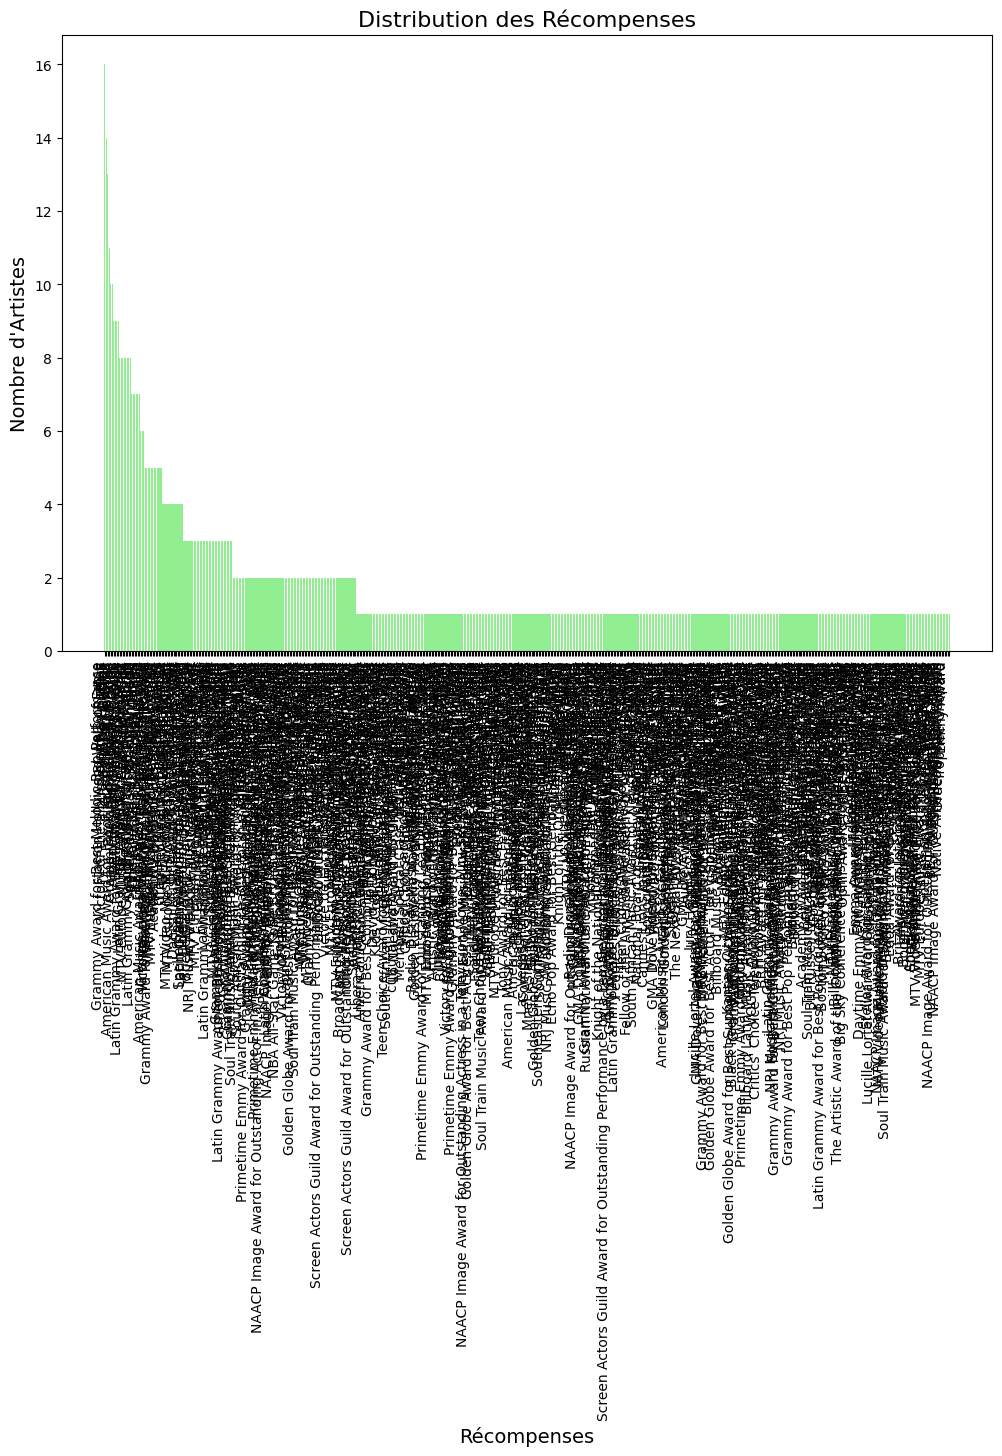

In [40]:
# Vérification de la distribution des récompenses (sans fusion)
award_data = results["award"]

# Affichage de la distribution des récompenses par type de récompense
plt.figure(figsize=(12, 8))
plt.bar(award_data["award_label"], award_data["count"], color='lightgreen')
plt.xticks(rotation=90, ha='right')
plt.title("Distribution des Récompenses", fontsize=16)
plt.xlabel("Récompenses", fontsize=14)
plt.ylabel("Nombre d'Artistes", fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Créer la table croisée
award_genre_cross_tab = pd.crosstab(award_genre_df["award_label"], award_genre_df["genre_label"])

# Vérification si les données sont numériques
print("\nCheck if the table contains numeric data:")
print(award_genre_cross_tab.dtypes)

# Visualisation avec un barplot empilé si les données sont numériques
if award_genre_cross_tab.dtypes.all() == 'int64':  # Vérifier si tous les types sont numériques
    award_genre_cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab20b')
    plt.title("Répartition des Genres Musicaux par Récompense", fontsize=16)
    plt.xlabel("Récompenses", fontsize=14)
    plt.ylabel("Nombre de Genres Musicaux", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("\nTable croisée contient des valeurs non numériques.")



Check if the table contains numeric data:
Series([], dtype: object)

Table croisée contient des valeurs non numériques.


In [34]:
# Afficher toutes les lignes fusionnées, sans supprimer les NaN pour voir la structure
print(award_genre_df)

# Vérifier les genres et récompenses non correspondants
no_award_genres = award_genre_df[award_genre_df["award_label"].isna()]
print(f"Genres sans récompenses :\n{no_award_genres}")


                 genre_label  count_x award_label  count_y
0                    hip-hop     3127         NaN      NaN
1                 trap music      520         NaN      NaN
2                    rapping      465         NaN      NaN
3           contemporary R&B      378         NaN      NaN
4                  pop music      364         NaN      NaN
..                       ...      ...         ...      ...
440                breakcore        1         NaN      NaN
441                 cantopop        1         NaN      NaN
442      underground culture        1         NaN      NaN
443  Native American hip hop        1         NaN      NaN
444                Afro-funk        1         NaN      NaN

[445 rows x 4 columns]
Genres sans récompenses :
                 genre_label  count_x award_label  count_y
0                    hip-hop     3127         NaN      NaN
1                 trap music      520         NaN      NaN
2                    rapping      465         NaN      NaN
3     

In [35]:
# Compter les genres ayant des récompenses associées
genres_with_award = award_genre_df[award_genre_df["award_label"].notna()]
print(f"Genres avec récompenses associées : {genres_with_award.shape[0]}")

# Compter les genres sans récompenses associées
genres_without_award = award_genre_df[award_genre_df["award_label"].isna()]
print(f"Genres sans récompenses associées : {genres_without_award.shape[0]}")


Genres avec récompenses associées : 0
Genres sans récompenses associées : 445


In [27]:
# Créer une table croisée en comptant les genres par récompense
award_genre_cross_tab = pd.crosstab(award_genre_df["award_label"], award_genre_df["genre_label"])

# Vérifier si la table croisée contient des données numériques
print(award_genre_cross_tab)

# Visualiser la table croisée sous forme de barplot empilé
award_genre_cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab20b')

# Ajouter le titre et les labels
plt.title("Répartition des Genres Musicaux par Récompense", fontsize=16)
plt.xlabel("Récompenses", fontsize=14)
plt.ylabel("Nombre de Genres Musicaux", fontsize=14)

# Rotation des étiquettes pour les rendre lisibles
plt.xticks(rotation=45, ha="right", fontsize=12)

# Ajuster la mise en page pour éviter que les labels se chevauchent
plt.tight_layout()

# Afficher le plot
plt.show()


NameError: name 'award_genre_df' is not defined

In [11]:
l= len(df_r[df_r['effectif'] < 10])
print(l)

960


**Comment**: An extreme difference in distribution can be observed: four occupational categories are ten to thirty times larger than the others.

There are 443 occupations with only one person and 800 with less than 10 persons, for a total of 966 different occupations.

### Graphically represent the frequency distribution

There is a wide dispersion of values and a predominant position for activities involving 10 or fewer people

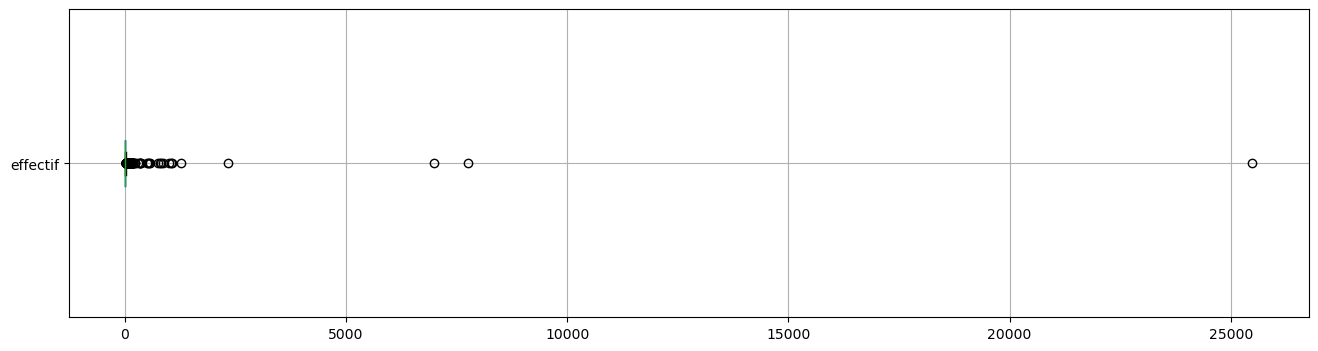

In [12]:
### Distribution des effectifs par occupation
ax = df_r.boxplot(column=['effectif'], vert=False, figsize=(16,4))

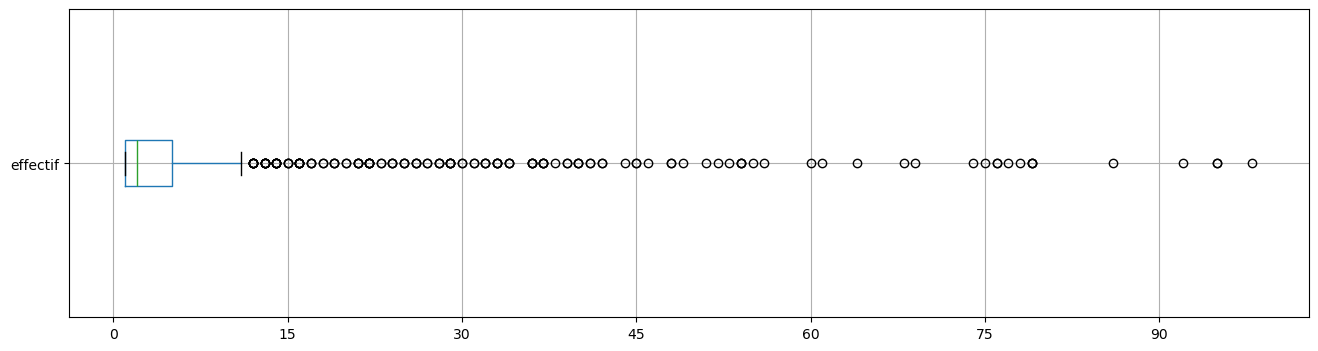

In [13]:
### Distribution des effectifs par occupation
ax = df_r[df_r.effectif<100].boxplot(column=['effectif'], vert=False, figsize=(16,4))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

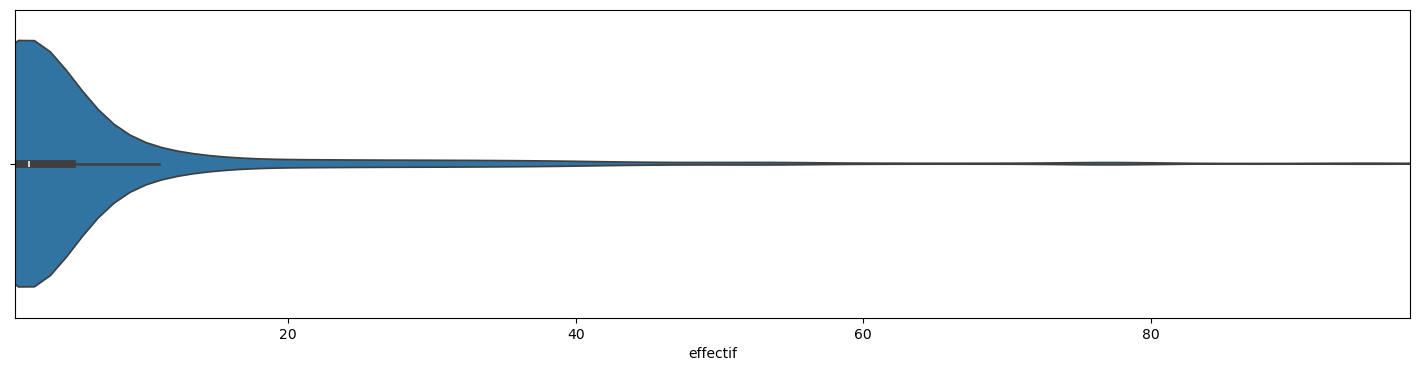

In [14]:
### Represent the density (the total surface has frequency = 1)
# https://seaborn.pydata.org/generated/seaborn.violinplot.html

plt.figure(figsize=(18,4))
d = df_r[df_r.effectif<100].effectif

ax = sns.violinplot(x = d)


### Noter que au delà des limites les valeurs sont coupées car postulées
ax.set_xlim(left=min(d), right=max(d))
plt.show()

### Group by frequency range

In [15]:
### Set the thresholds

ls = [1, 5, 10, 20, 50, 100, 200, 300, 500, 1000, 30000]
print(ls)

[1, 5, 10, 20, 50, 100, 200, 300, 500, 1000, 30000]


In [16]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

df_r['seuils'] = pd.cut(df_r['effectif'], ls, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_r['seuils'] = df_r['seuils'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_r.head(3)

,uri,label,effectif,seuils
0,http://www.wikidata.org/entity/Q169470,physicist,25489,1000-29999
1,http://www.wikidata.org/entity/Q1622272,university teacher,7750,1000-29999
2,http://www.wikidata.org/entity/Q11063,astronomer,6990,1000-29999


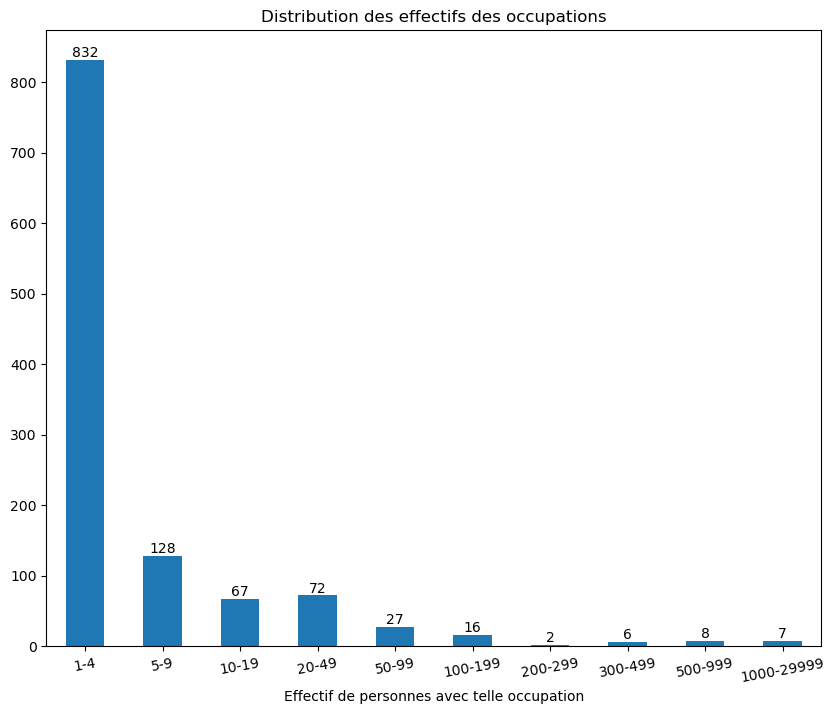

In [17]:
# Plot the grouped distribution

ax = df_r.groupby(by='seuils', observed=False).size()\
    .plot(kind='bar',rot=10, fontsize=10, figsize=(10,8))
ax.bar_label(ax.containers[-1], fontsize=10)
plt.xlabel('Effectif de personnes avec telle occupation')
plt.title('Distribution des effectifs des occupations')
plt.show()

### Inspect the values

In [18]:
print(df_r[df_r['effectif'] == 1].head(10).label)

631                      architectural draftsperson
632                                    data analyst
633                              materials engineer
634                                   chess teacher
635                                general director
636                     chartered building surveyor
637                                       waka poet
638    ingénieurs et cadres techniques d'entreprise
639                                           hiker
640                             industrial designer
Name: label, dtype: object


In [19]:
print(df_r[df_r['effectif'] == 5].head(10).label)

297        electronician
298              athlete
299              scholar
300        lexicographer
301         technologist
302     nanotechnologist
303          academician
304       epistemologist
305    software engineer
306                tutor
Name: label, dtype: object


In [20]:
print(df_r[df_r['effectif'] == 10].head(10).label)

191             philologist
192    athletics competitor
193          peace activist
194                 soldier
195     theoretical chemist
196              topologist
197         design engineer
198    professor of physics
199         mining engineer
200                youtuber
Name: label, dtype: object


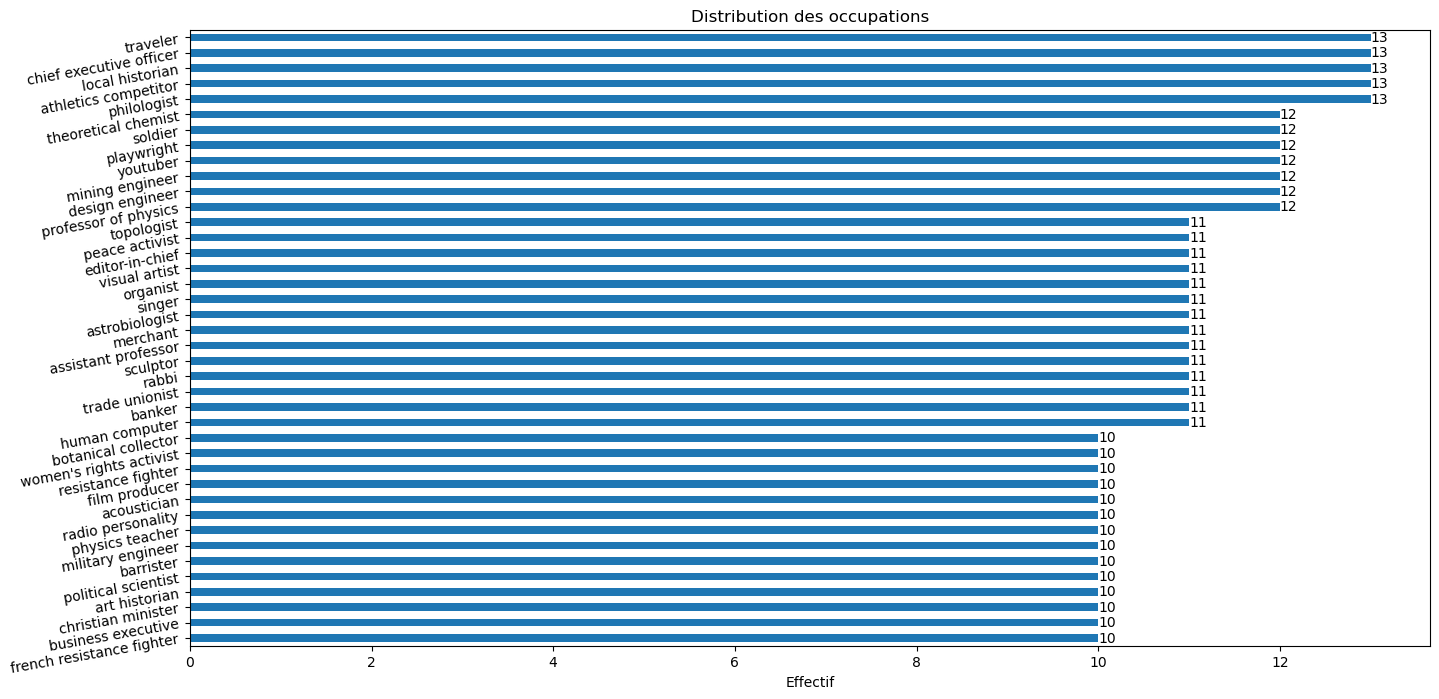

In [21]:
### Bar chart representing the distribution by ‘occupation’ 
# in a given frequency range

d = df_r[(df_r.effectif < 100)&(df_r.effectif > 9)].sort_values(by='effectif',ascending=True).head(40)
ax = d.effectif.plot(kind='barh',rot=10, fontsize=10, figsize=(16,8))
y_labels = reversed(d.label.to_list())
ax.set_yticklabels(y_labels)
ax.bar_label(ax.containers[-1])
plt.xlabel('Effectif')
plt.title('Distribution des occupations')
plt.show()

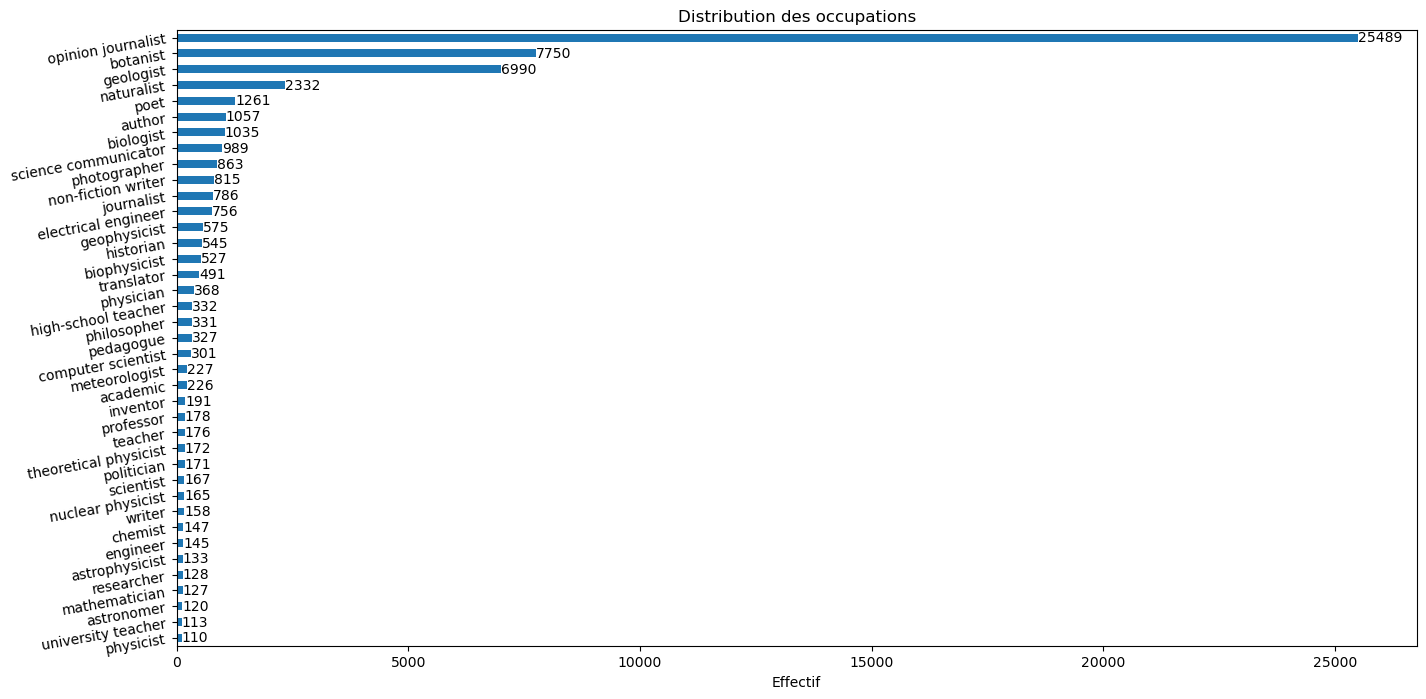

In [22]:
### Bar chart representing the distribution by ‘occupation’ 
# in a given frequency range

d = df_r[df_r.effectif > 100].sort_values(by='effectif',ascending=True)
ax = d.effectif.plot(kind='barh',rot=10, fontsize=10, figsize=(16,8))
y_labels = reversed(d.label.to_list())
ax.set_yticklabels(y_labels)
ax.bar_label(ax.containers[-1])
plt.xlabel('Effectif')
plt.title('Distribution des occupations')
plt.show()

**Comment**

Observation of the typology of occupations reveals a variety that leads to two different types of questions: 
* the specificities of profiles within scientific disciplines
* other activities (artistic, economic, etc.) in their relationship with the disciplines


The aim will be to better define the question or questions we wish to address and to use the information available in Wikidata to create classes.


Another question we could raise is the *changing distribution and configuration over tim*e.

Another question we could ask is the changing distribution and configuration over time. To answer this question, we should add the birth years or generations of the individuals to the characteristics of the occupations.


## Explore the number of occupations per person

In [10]:
### Basic query regarding persons' occupations

query = """PREFIX franzOption_defaultDatasetBehavior: <franz:rdf>
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?item ?itemLabel (COUNT(*) as ?n)
WHERE {
    GRAPH <https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/graphs/wikidata-imported-data.md>
        {?item wdt:P106 ?occupation.
        OPTIONAL {?item rdfs:label ?itemLabel}    
          }
}
GROUP BY ?item ?itemLabel
ORDER BY DESC(?n)
LIMIT 500
"""

In [11]:
### Executer la requête avec les fonctions de la librairie locale
qr = spqf.get_json_sparql_result(endpoint,query)

In [12]:
r = [l for l in spqf.sparql_result_to_list(qr)]
print(len(r))
r[:3]

500


[['http://www.wikidata.org/entity/Q6694', 'Alexander von Humboldt', '24'],
 ['http://www.wikidata.org/entity/Q78061707', 'Simon Villeneuve', '23'],
 ['http://www.wikidata.org/entity/Q470334', 'Euclides da Cunha', '16']]

In [26]:
### Transform the results to a dataframe
df_r = pd.DataFrame(r)
df_r.columns=['uri', 'label', 'effectif']
df_r['effectif'] = df_r.effectif.apply(lambda x : int(x))
df_r.head()

,uri,label,effectif
0,http://www.wikidata.org/entity/Q6694,Alexander von Humboldt,24
1,http://www.wikidata.org/entity/Q78061707,Simon Villeneuve,23
2,http://www.wikidata.org/entity/Q470334,Euclides da Cunha,16
3,http://www.wikidata.org/entity/Q410,Carl Sagan,16
4,http://www.wikidata.org/entity/Q5609050,Grigorie Sturdza,15


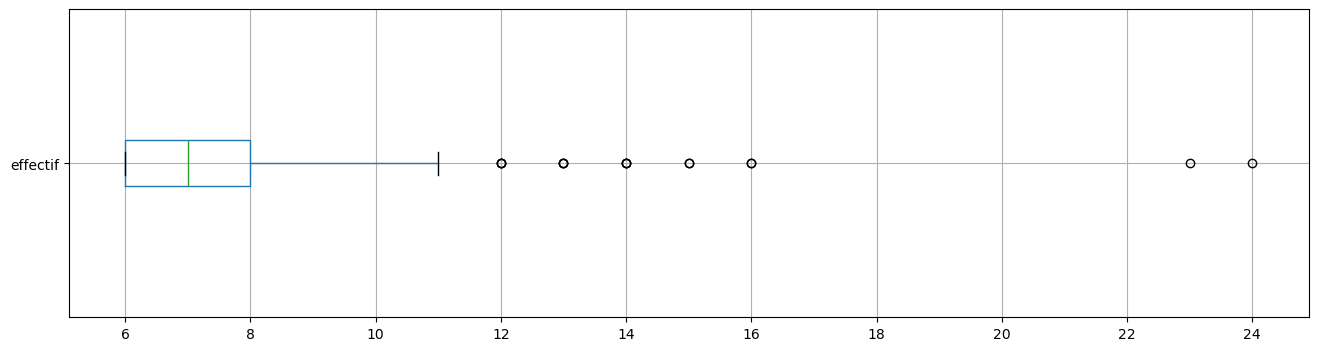

In [27]:
### Distribution of frequencies per person
ax = df_r.boxplot(column=['effectif'], vert=False, figsize=(16,4))

## this fuction avoids ticks with floats instead of integers
#  on the x axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

**Comment**

Most persons have between 6 and 8 occupations, with some outliers

86


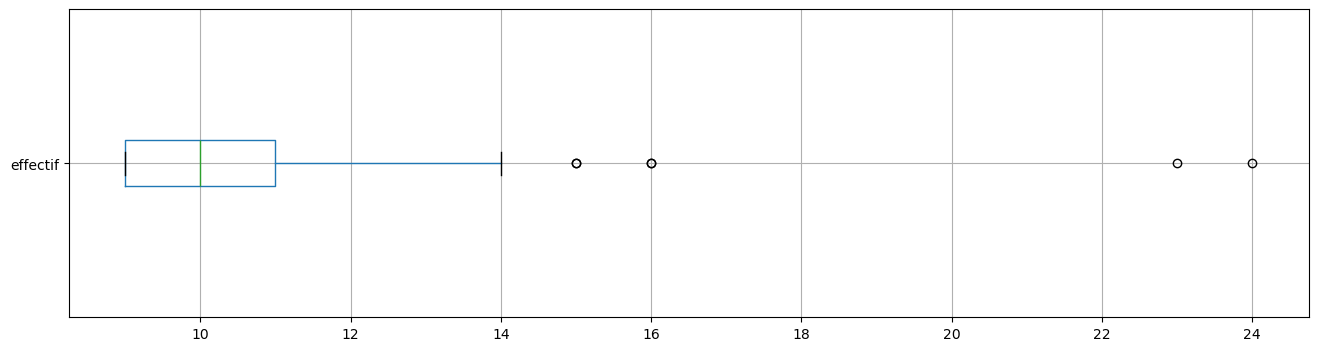

In [28]:
### Distribution des effectifs par occupation

d = df_r[df_r.effectif > 8]
print(len(d))

ax = d.boxplot(column=['effectif'], vert=False, figsize=(16,4))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

In [29]:
### Cf. the profiles of these persons in Wikidata
pprint.pprint(d.tail())

                                          uri               label  effectif
81     http://www.wikidata.org/entity/Q937063     Tomas M. Milich         9
82     http://www.wikidata.org/entity/Q330225  Eugene Rabinowitch         9
83  http://www.wikidata.org/entity/Q112042673    George Stranahan         9
84     http://www.wikidata.org/entity/Q239131   Evelyn Fox Keller         9
85    http://www.wikidata.org/entity/Q3129074      Heather Couper         9


## Parent occupations

We can try to use the taxonomy of occupations to select relevant occupations.

We therefore go back to the [Import sparqlbook](../../sparqlbooks/wdt_import_occupations.sparqlbook)

In [13]:
query = """
## 

### Simplified query

PREFIX franzOption_defaultDatasetBehavior: <franz:rdf>
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wikibase: <http://wikiba.se/ontology#>
PREFIX bd: <http://www.bigdata.com/rdf#>

SELECT DISTINCT 
?occupation ?occupationLabel ?parentField ?parentFieldLabel
?n
          #?parentKnowledgeClassification ?parentKnowledgeClassificationLabel 
          # (SUM(?n) as ?sn)
WHERE {
    GRAPH <https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/graphs/wikidata-imported-data.md>
        {
          SELECT ?occupation ?occupationLabel
          ?parentOccupation (COUNT(*) as ?n)
        
        WHERE
        {
          ?s a wd:Q5;  
              wdt:P106 ?occupation.
          ?occupation rdfs:label ?occupationLabel.
          ?occupation  wdt:P279  ?parentOccupation.
          }  
        GROUP BY ?occupation ?occupationLabel
          ?parentOccupation
        }

        SERVICE <https://query.wikidata.org/sparql>
          {
              # field of parent occupation / instance of /  subclass of  
              ?parentOccupation wdt:P425 / wdt:P31 ?parentField.
              # ?parentField wdt:P279 ?parentKnowledgeClassification.


              #BIND (?occupation as ?occupationLabel)
              BIND (?parentFieldLabel as ?parentFieldLabel)
              # BIND (?parentKnowledgeClassificationLabel as ?parentKnowledgeClassificationLabel)
              SERVICE wikibase:label { bd:serviceParam wikibase:language "en". } 
          }

}
# GROUP BY ?occupation ?occupationLabel ?parentField ?parentFieldLabel
          # ?parentKnowledgeClassification ?parentKnowledgeClassificationLabel 
ORDER BY DESC(?n)
"""

In [14]:
### Executer la requête avec les fonctions de la librairie locale
qr = spqf.get_json_sparql_result(endpoint,query)

In [15]:
r = [l for l in spqf.sparql_result_to_list(qr)]
print(len(r))
r[:3]

3077


[['http://www.wikidata.org/entity/Q169470',
  'physicist',
  'http://www.wikidata.org/entity/Q2465832',
  'branch of science',
  '25489'],
 ['http://www.wikidata.org/entity/Q169470',
  'physicist',
  'http://www.wikidata.org/entity/Q11862829',
  'academic discipline',
  '25489'],
 ['http://www.wikidata.org/entity/Q1622272',
  'university teacher',
  'http://www.wikidata.org/entity/Q2465832',
  'branch of science',
  '7750']]

In [16]:
### Transform the results to a dataframe
df_r = pd.DataFrame(r)
df_r.columns=['uriOccupation', 'labelOccupation', 'uriDomaine', 'labelDomain', 'size']
# df_r['size'] = df_r.size.apply(lambda x : int(x))
df_r.head()

,uriOccupation,labelOccupation,uriDomaine,labelDomain,size
0,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q2465832,branch of science,25489
1,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q11862829,academic discipline,25489
2,http://www.wikidata.org/entity/Q1622272,university teacher,http://www.wikidata.org/entity/Q2465832,branch of science,7750
3,http://www.wikidata.org/entity/Q1622272,university teacher,http://www.wikidata.org/entity/Q26256810,topic,7750
4,http://www.wikidata.org/entity/Q1622272,university teacher,http://www.wikidata.org/entity/Q130303173,service type,7750


In [23]:

## [gb_oc['size'] > 4 ]

show(df_r,  scrollY="300px",
     scrollCollapse=True, paging=False, layout={"topEnd": None}, 
     showIndex=False, column_filters="header", 
     columnDefs=[{"className": "dt-left", "targets": "_all"}],
     #search={"regex": True, "caseInsensitive": True},
     # https://mwouts.github.io/itables/downsampling.html
       maxBytes=0)

Loading... (need help?)


In [2]:
query = """
### Occupation classifications

PREFIX franzOption_defaultDatasetBehavior: <franz:rdf>
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?birthYear ?o ?oLabel ?oP ?oPLabel
WHERE {
    GRAPH <https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/graphs/wikidata-imported-data.md>
        {?item a wd:Q5;
            wdt:P569 ?birthYear;
            wdt:P106 ?o.
        ?o a wd:Q12737077;
            wdt:P279 ?o1.
        OPTIONAL {?o rdfs:label ?oLabel}    
        OPTIONAL {?oP rdfs:label ?oPLabel}    
          }
}
ORDER BY ?s
"""

In [3]:
### Executer la requête avec les fonctions de la librairie locale
qr = spqf.get_json_sparql_result(endpoint,query)

NameError: name 'spqf' is not defined

In [1]:
r = [l for l in spqf.sparql_result_to_list(qr)]
print(len(r))
r[:3]

NameError: name 'spqf' is not defined

In [ ]:
### Transform the results to a dataframe
df_r = pd.DataFrame(r)
df_r.columns=['year', 'oc_uri', 'oc_label', 'op_uri', 'op_label']
df_r['year'] = df_r.year.apply(lambda x : int(x))
df_r.head()

,year,oc_uri,oc_label,op_uri,op_label
0,1923,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q124637774,physical scientist
1,1908,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q124637774,physical scientist
2,1882,http://www.wikidata.org/entity/Q3126128,geneticist,http://www.wikidata.org/entity/Q864503,biologist
3,1937,http://www.wikidata.org/entity/Q1650915,researcher,http://www.wikidata.org/entity/Q66666685,academic professional
4,1937,http://www.wikidata.org/entity/Q1650915,researcher,http://www.wikidata.org/entity/Q15980158,non-fiction writer


### Codage par période de cinquante ans

In [ ]:
### Créer une liste d'années pour séparer en périodes de 50 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
d = list(range(1751, 2001, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1751, 1776, 1801, 1826, 1851] [1851, 1876, 1901, 1926, 1951] 8


In [ ]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

df_r['per_25'] = pd.cut(df_r['year'], l_25, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_r['per_25'] = df_r['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_r.head(3)

,year,oc_uri,oc_label,op_uri,op_label,per_25
0,1923,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q124637774,physical scientist,1901-1925
1,1908,http://www.wikidata.org/entity/Q169470,physicist,http://www.wikidata.org/entity/Q124637774,physical scientist,1901-1925
2,1882,http://www.wikidata.org/entity/Q3126128,geneticist,http://www.wikidata.org/entity/Q864503,biologist,1876-1900


In [ ]:
### distribution des naissances par périodes de 25 ans
naissances_per = df_p.groupby(by='per_25').size()
print(naissances_per)

per_25
1751-1775     254
1776-1800     326
1801-1825     532
1826-1850     809
1851-1875    1312
1876-1900    1916
1901-1925    4210
1926-1950    8132
dtype: int64


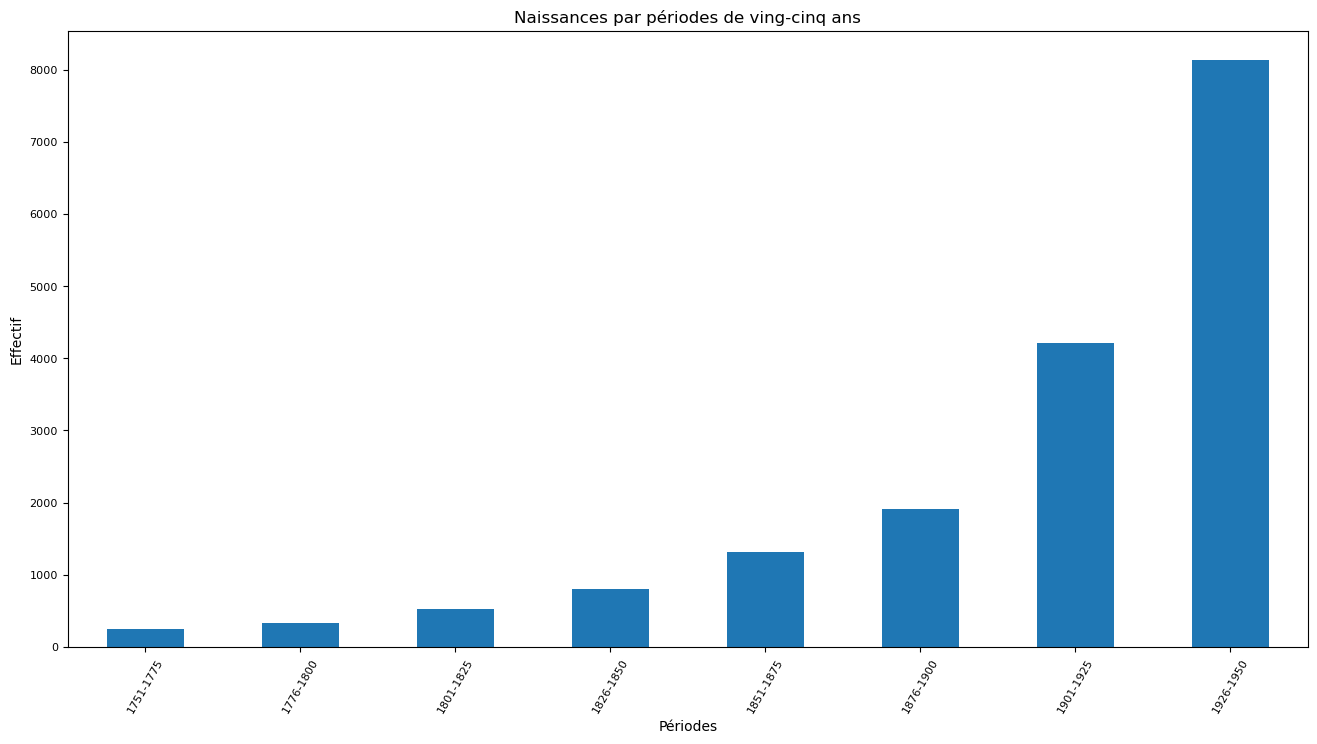

In [ ]:
### Diagramme à barres représentant la distribution par 'génération'
ax = df_p.groupby(by='per_25').size().plot(kind='bar',rot=60, fontsize=8, figsize=(16,8))
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Naissances par périodes de ving-cinq ans')
plt.show()

In [ ]:
### distribution des naissances par périodes de 25 ans
gb_oc = df_r.groupby(by=['oc_label','op_label'], observed=False, as_index=False).size()
print(len(gb_oc))
gb_oc.head()

1462


,oc_label,op_label,size
0,Aliyah Bet activist,political activist,2
1,Anglican priest,Anglican clergyman,4
2,Anglican priest,Western priest,4
3,Bible translator,biblical scholar,2
4,Bible translator,translator,2


In [ ]:

## [gb_oc['size'] > 4 ]

show(gb_oc.sort_values(by='size', ascending=False),  scrollY="300px",
     scrollCollapse=True, paging=False, layout={"topEnd": None}, 
     showIndex=False, column_filters="header", columnDefs=[{"className": "dt-left", "targets": "_all"}],
     # https://mwouts.github.io/itables/downsampling.html
       maxBytes=0)

Loading... (need help?)


## A faire : articuler / séparer la population entre astronomees et physiciens
Chois heuristique de base

# La suite est en préparation

## Paires d'occupations

In [ ]:
query = """
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX wikibase: <http://wikiba.se/ontology#>
PREFIX bd: <http://www.bigdata.com/rdf#>
PREFIX franzOption_defaultDatasetBehavior: <franz:rdf>

## Pour avoir les données avec la personne et l'effectif de toutes les relations
# SELECT DISTINCT ?item ?occupation ?occupationLabel ?occupation_1 ?occupation_1Label

SELECT ?occupation ?occupationLabel ?occupation_1 ?occupation_1Label
WHERE
  {GRAPH <https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/graphs/wikidata-imported-data.md>
     {
      ?item wdt:P106 ?occupation.
      ?item wdt:P106 ?occupation_1.
      ?occupation rdfs:label ?occupationLabel.
      ?occupation_1 rdfs:label ?occupation_1Label.
      FILTER (str(?occupationLabel) < str(?occupation_1Label))
      } 

      }
"""

In [ ]:
### Executer la requête avec les fonctions de la librairie locale
qr = spqf.get_json_sparql_result(endpoint,query)

In [ ]:
r = [l for l in spqf.sparql_result_to_list(qr)]
print(len(r))
r[:3]

In [ ]:
### Transform the results to a dataframe
df_r = pd.DataFrame(r)
df_r.columns=['uri', 'label', 'uri_1', 'label1_']
df_r.uri = df_r.uri.apply(lambda x : x.replace('http://www.wikidata.org/entity/', ''))
df_r.uri_1 = df_r.uri_1.apply(lambda x : x.replace('http://www.wikidata.org/entity/', ''))
df_r.head()

In [ ]:
list(df_r.columns)

In [ ]:
gr = pd.DataFrame(df_r.groupby(['uri', 'label', 'uri_1', 'label1_']).size())
gr.reset_index(inplace=True)
gr.columns=list(df_r.columns)+['size']
gr.sort_values(by='size', ascending=False).head(40)

In [ ]:
gr.sort_values(by='size', ascending=False).tail(40)

In [ ]:
### Distribution des effectifs par occupation
ax = gr.boxplot(column=['size'], vert=False, figsize=(16,4))

In [ ]:
### Distribution des effectifs par occupation
ax = gr[(gr['size']>10) & (gr['size']<500)].boxplot(column=['size'], vert=False, figsize=(16,4))

In [ ]:
ax = gr['size'].plot(kind='bar',rot=10, fontsize=10, figsize=(10,8))
ax.bar_label(ax.containers[-1], fontsize=10)
plt.xlabel('Effectif de personnes avec telle occupation')
plt.title('Distribution des effectifs des occupations')
plt.show()

In [ ]:
plt.figure(figsize=(15, 4))
d = gr[(gr['size'] > 0) & (gr['size'] < 10)]['size']
#d = gr['size']


ax = sns.barplot(x = d)
ax.set_xlim(left=min(d), right=max(d))

ax.plot()

In [ ]:
show(gr[gr['size'] > 4 ].sort_values(by='size', ascending=False),  scrollY="300px",
     scrollCollapse=True, paging=False, layout={"topEnd": None}, 
     showIndex=False, column_filters="header", columnDefs=[{"className": "dt-left", "targets": "_all"}],
     # https://mwouts.github.io/itables/downsampling.html
       maxBytes=0)

## Graphe

In [ ]:


l = []
for i in gr[gr['size'] > 10 ]:
    l.append(tuple((i['uri'],i['uri_1'])))
l[:5]



### A faire

* ajouter ITable pour exploration
* regrouper par type de valeurs
*
* 